# Исследование и анализ датасета

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [188]:
RANDOM_STATE = 42

In [189]:
df = pd.read_excel("../data/raw_data.xlsx", index_col=0)
df.head()

,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0


In [190]:
df.shape

(1001, 213)

В файле содержится 3 таргета и 210 признаков. Проверим есть ли там пропуски

In [191]:
df.isna().sum().sum()

np.int64(36)

Пропуски нашлись, всего 36 значений. Найдем столбцы с пропусками.

In [192]:
missing_data = df.isna().sum()
print(missing_data[missing_data > 0])

MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
MinAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPHI          3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3
dtype: int64


Попробуем удалить строки с пропусками. Возможно это всего три строки на весь датасет.

In [193]:
df_cleaned = df.dropna(subset=['MaxPartialCharge'])
df_cleaned.shape

(998, 213)

Так и есть, пропуски занимали три строки из 1001.

Посмотрим на выбросы в данных.

In [194]:
# границы IQR для каждого признака
Q1 = df_cleaned.quantile(0.25)
Q3 = df_cleaned.quantile(0.75)
IQR = Q3 - Q1

# количество выбросов в каждой колонке
outliers = ((df_cleaned < (Q1 - 1.5 * IQR)) | (df_cleaned > (Q3 + 1.5 * IQR))).sum()

outliers_sorted = outliers[outliers > 0].sort_values(ascending=False)

print("Топ-10 признаков по количеству выбросов:")
print(outliers_sorted.head(10))

print(f"\nОбщий процент аномальных значений в датасете: {outliers.sum() / df_cleaned.size * 100:.2f}%")

Топ-10 признаков по количеству выбросов:
VSA_EState10       247
VSA_EState9        243
fr_amide           243
fr_Al_OH           243
fr_aniline         222
Ipc                218
fr_allylic_oxid    209
PEOE_VSA4          205
fr_ester           199
PEOE_VSA13         185
dtype: int64

Общий процент аномальных значений в датасете: 4.79%


In [195]:
df_cleaned[outliers_sorted.index[:10].tolist()].describe()

,VSA_EState10,VSA_EState9,fr_amide,fr_Al_OH,fr_aniline,Ipc,fr_allylic_oxid,PEOE_VSA4,fr_ester,PEOE_VSA13
count,998.000000,998.000000,998.000000,998.000000,998.000000,9.980000e+02,998.000000,998.000000,998.000000,998.000000
mean,1.005513,0.569104,0.341683,0.404810,0.299599,4.846227e+10,0.335671,2.956084,0.220441,1.185002
std,2.230156,1.684041,0.701400,1.041976,0.659336,1.257854e+12,0.796526,6.731609,0.477690,2.627704
min,0.000000,-7.681287,0.000000,0.000000,0.000000,1.071072e+02,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,1.906764e+04,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.138605e+05,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,4.409676e+06,0.000000,0.000000,0.000000,0.000000
max,15.553441,10.183618,4.000000,12.000000,4.000000,3.951781e+13,8.000000,44.612417,4.000000,17.721539


Проанализируем данные, которые кажутся выбросами. Колонки fr_amide, fr_Al_OH, fr_aniline, fr_allylic_oxid, fr_ester содержат данные о количестве специфических функциональных групп у химического соединения. От минимального значения и до 75% процентиля в значениях содержатся 0.0, но у небольшой части химических соединений эти признаки не пусты, и принимаю целое число. Поэтому считать их выбросами нельзя, это важные признаки веществ.

Ipc индекс содержащий в себе информацию о разветвленности молекулы, из данных видно, что молекулы в датасете разной сложности, и размера.

Данные требуют нормализации перед обучением моделей, поскольку порядки значений очень различны. Для стнадартизации используем RobustScaler, поскольку он устойчив к выбросам и использует медиану и межквартильный размах.

Посмотрим на распределения целевых данных. Так же попробуем логарифмировать таргет и сравнить распределение.

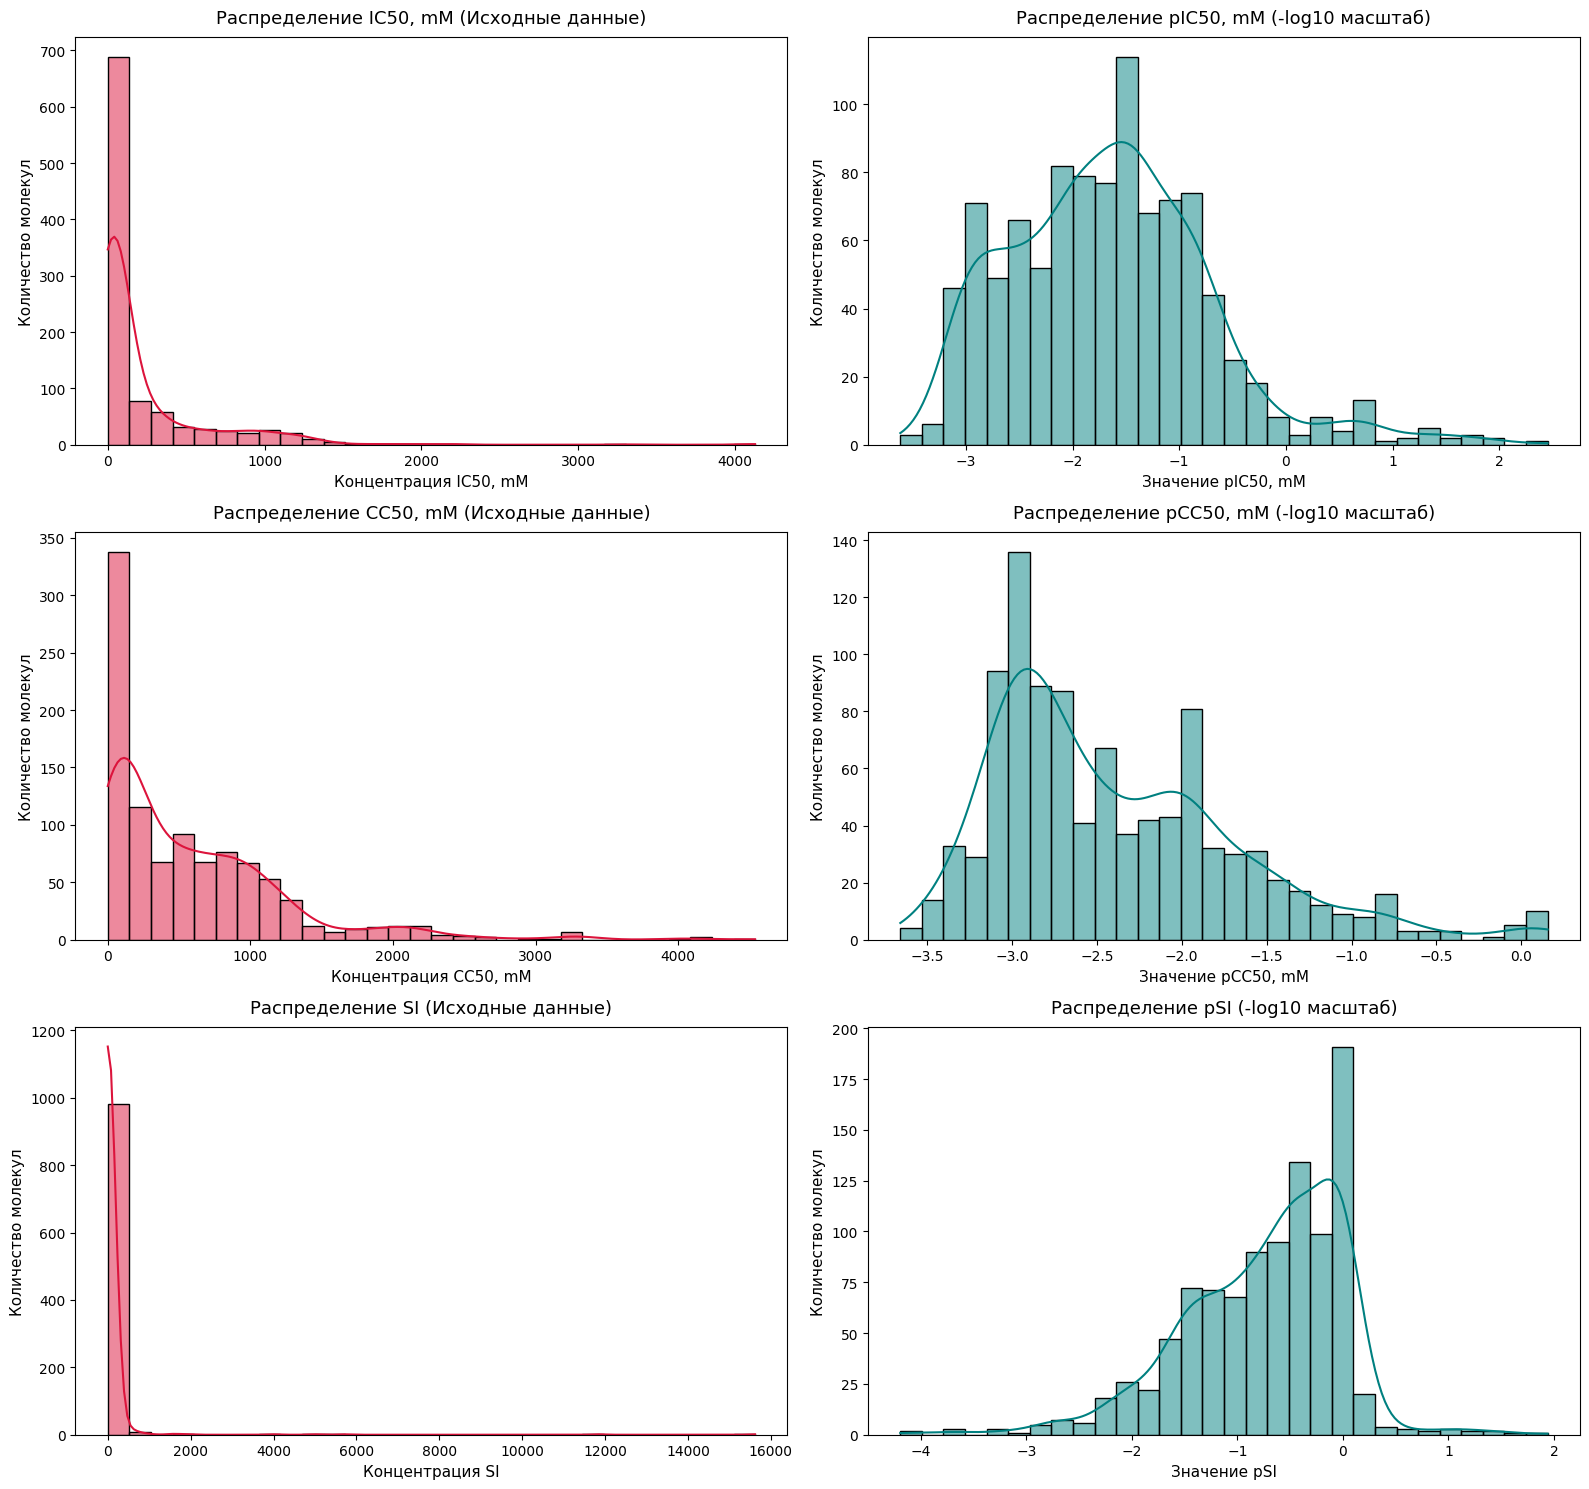

In [196]:
targets_columns = ['IC50, mM', 'CC50, mM', 'SI']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 15))

for i, target in enumerate(targets_columns):
   
    sns.histplot(df_cleaned[target], kde=True, color='crimson', bins=30, ax=axes[i, 0])
    axes[i, 0].set_title(f'Распределение {target} (Исходные данные)', fontsize=13, pad=10)
    axes[i, 0].set_xlabel(f'Концентрация {target}', fontsize=11)
    axes[i, 0].set_ylabel('Количество молекул', fontsize=11)
    
    sns.histplot(-np.log10(df_cleaned[target].clip(lower=1e-4)), kde=True, color='teal', bins=30, ax=axes[i, 1])
    axes[i, 1].set_title(f'Распределение p{target} (-log10 масштаб)', fontsize=13, pad=10)
    axes[i, 1].set_xlabel(f'Значение p{target}', fontsize=11)
    axes[i, 1].set_ylabel('Количество молекул', fontsize=11)

plt.tight_layout()
plt.show()

Видим, что исходное распределение похоже на логонормальное. На графиках вадна очень сильная асимметрия, с длинным правым хвостом. Если мы возьмем по исходным данным отрицательный логарифм, то получим распределение близкое к нормальному. Используем преобразованные данные для обучения.

Посмотрим какие признаки линейно влияют на наши таргеты.

In [197]:
for target in targets_columns:
    y = df_cleaned[target].clip(lower=1e-4)
    X = df_cleaned.drop(columns=targets_columns)
    X = X.loc[:, X.std() > 0]
    correlations = X.apply(lambda x: x.corr(y))
    abs_correlations = correlations.abs().sort_values(ascending=False)
    top_3_features = abs_correlations.head(3).index.tolist()
    
    print(f"\nТоп-3 признака по Пирсону для {target}:")
    for col in top_3_features[:5]:
        print(f"  {col}: r = {correlations[col]:.4f}")


Топ-3 признака по Пирсону для IC50, mM:
  VSA_EState4: r = -0.2717
  Chi2n: r = -0.2527
  PEOE_VSA7: r = -0.2508

Топ-3 признака по Пирсону для CC50, mM:
  LabuteASA: r = -0.3078
  MolMR: r = -0.3073
  MolWt: r = -0.3049

Топ-3 признака по Пирсону для SI:
  BalabanJ: r = 0.1647
  fr_NH2: r = 0.1604
  RingCount: r = -0.1248


Видим, что среди признаков нет попарно линейно скоррелированных с таргетами. Тем не менее, модель множественной линейной регрессии с регуляризацией (Ridge Regression) будет обучена в качестве бейзлайна.

## Предобработка данных и подбор наиболее значимых признаков для задач регрессии и классификации

Выберем таргеты и признаки

In [198]:
targets = df_cleaned[targets_columns]

X = df_cleaned.drop(columns=targets_columns)

Разделим данные на обучающую и тестовую подвыборки

In [199]:
X_train, X_test, targets_train, targets_test = train_test_split(X, targets, test_size=0.2, random_state=RANDOM_STATE)

Логарифмируем таргеты

In [200]:
targets_train = -np.log10(targets_train.clip(lower=1e-4))
targets_test = -np.log10(targets_test.clip(lower=1e-4))

Сначала отсеем признаки с очень малой вариацией, которые наиболее близки к константе.

In [201]:
selector = VarianceThreshold(threshold=0.01).set_output(transform="pandas")
X_train_reduced = selector.fit_transform(X_train)
X_test_reduced = selector.transform(X_test)

print(f"После удаления константных признаков осталось {X_train_reduced.shape[1]} колонок из {X_train.shape[1]}")

После удаления константных признаков осталось 176 колонок из 210


Теперь стандартизируем признаки при помощи RobustScaler

In [202]:
scaler = RobustScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

Найдем однозначно скоррелированные между собой признаки, без визуального построения матрицы корреляций, так как признаком слишком много

In [203]:
threshold=0.90

corr_matrix = X_train_scaled.corr().abs()
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_matrix = corr_matrix.where(mask)

to_drop = [column for column in upper_matrix.columns if any(upper_matrix[column] > threshold)]
len(to_drop)

46

Удалим найденные сильно скоррелированные признаки. Это важно для дальнейшего обучения CatBoost и SVR моделей

In [204]:
X_train_scaled = X_train_scaled.drop(columns=to_drop)
X_test_scaled = X_test_scaled.drop(columns=to_drop)

In [213]:
X_train_scaled.shape[1]

129

Выберем для каждого таргета том-30 лучших признаков, обучив RandomForestRegressor и выбирая рекомендованные ей фичи. Выбранные признаки подойдут для обучения моделей регрессии, а так же классификации, в которых требуется сравнение таргета с медианой. 

In [205]:
from sklearn.ensemble import RandomForestRegressor
best_features_by_target = {}

for target in targets_columns:
   
    y_train = targets_train[target]

    model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(X_train_scaled, y_train)

    # Создаем датафрейм со значениями важности
    importances = pd.DataFrame(
        {"Feature": X_train_scaled.columns, "Importance": model.feature_importances_}
    ).sort_values(by="Importance", ascending=False)

    selected_features = importances.head(30)["Feature"].tolist()
    best_features_by_target[target] = selected_features
    
    print(f"\nТоп-5 признаков для {target}:")
    print("="*50)
    print(importances.head(5))


Топ-5 признаков для IC50, mM:
             Feature  Importance
70       VSA_EState8    0.141337
17          BalabanJ    0.071471
67       VSA_EState4    0.046993
10      BCUT2D_CHGHI    0.041250
7   FpDensityMorgan1    0.029543

Топ-5 признаков для CC50, mM:
         Feature  Importance
73     NHOHCount    0.085710
9   BCUT2D_MWLOW    0.044996
30     PEOE_VSA7    0.042950
29     PEOE_VSA6    0.036250
15  BCUT2D_MRLOW    0.035031

Топ-5 признаков для SI:
         Feature  Importance
70   VSA_EState8    0.056982
17      BalabanJ    0.041953
11  BCUT2D_CHGLO    0.033344
72  FractionCSP3    0.031728
3            qed    0.029835


Мы получили по 30 самых значимых признаков для каждого таргета. Теперь сохраним подготовленные данные в файлы для обучения и теста каждой из трех видов регрессии.

In [206]:
output_dir = '../data/processed/'
for target in targets_columns:
    y_train = targets_train[target]
    y_test = targets_test[target]

    train_filename = f"{output_dir}{target.lower().split(',')[0]}_train.csv"
    test_filename = f"{output_dir}{target.lower().split(',')[0]}_test.csv"

    # объединяем выбранные фичи с одним таргетом и записываем в файл
    
    pd.concat([X_train_scaled[best_features_by_target[target]], y_train], axis=1).to_csv(train_filename, index=False)
    pd.concat([X_test_scaled[best_features_by_target[target]], y_test], axis=1).to_csv(test_filename, index=False)

## Предобработка и анализа данных для задачи классификации по SI > 8

Возьмем DataFrame очищенный от пропусков и добавим в него дополнительный таргет для классификации из задачи "превышает ли значение SI значение 8". Это необходимо для того, чтобы проанализировать сбалансированность данных по этому признаку и подобрать фичи для моделей классификации. Поскольку именно этот таргет требует отдельного набора параметров.

In [207]:
si8_y = (df_cleaned["SI"] > 8).astype(int)
si8_x = df_cleaned.drop(columns = targets_columns)

Посмотрим на сбалансированность классов.

In [208]:
si8_y.value_counts()

SI
0    642
1    356
Name: count, dtype: int64

Видим что выборка несбалансированна. Разделение данных необходимо провести с параметром stratify

In [209]:
X_train, X_test, y_train, y_test = train_test_split(si8_x, si8_y, test_size=0.2, random_state=RANDOM_STATE, stratify=si8_y)

Повторим процедуру фильтрации и стандартизации признаков для данной задачи.

In [210]:
# Отсеиваем признаки с очень малой вариацией, которые наиболее близки к константе.
selector = VarianceThreshold(threshold=0.01).set_output(transform="pandas")
X_train_reduced = selector.fit_transform(X_train)
X_test_reduced = selector.transform(X_test)

print(f"После удаления константных признаков осталось {X_train_reduced.shape[1]} колонок из {X_train.shape[1]}")

# Стандартизируем признаки
scaler = RobustScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train_reduced)
X_test_scaled = scaler.transform(X_test_reduced)

# Удаляем сильно попарно связанные признаки
threshold=0.90

corr_matrix = X_train_scaled.corr().abs()
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_matrix = corr_matrix.where(mask)

to_drop = [column for column in upper_matrix.columns if any(upper_matrix[column] > threshold)]

X_train_scaled = X_train_scaled.drop(columns=to_drop)
X_test_scaled = X_test_scaled.drop(columns=to_drop)

print(f"После скоррелированных признаков осталось {X_train_scaled.shape[1]} колонок")

После удаления константных признаков осталось 175 колонок из 210
После скоррелированных признаков осталось 129 колонок


Для модели классификации SI в сравнении с константой 8 необходимо подобрать специальный набор признаков.

In [211]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Создаем датафрейм со значениями важности
importances = pd.DataFrame(
    {"Feature": X_train_scaled.columns, "Importance": model.feature_importances_}
).sort_values(by="Importance", ascending=False)

selected_features = importances.head(30)["Feature"].tolist()
best_features_SI8 = selected_features

print(f"\nТоп-5 признаков для SI8:")
print("="*50)
print(importances.head(5))


Топ-5 признаков для SI8:
              Feature  Importance
11       BCUT2D_CHGLO    0.024460
0   MaxAbsEStateIndex    0.024437
67        VSA_EState4    0.024354
12      BCUT2D_LOGPHI    0.023215
9        BCUT2D_MWLOW    0.023017


Мы получили 30 самых значимых признаков для SI8. Теперь сохраним подготовленные данные в файлы для обучения и теста.

In [212]:
output_dir = '../data/processed/'
train_filename = f"{output_dir}si8_train.csv"
test_filename = f"{output_dir}si8_test.csv"

# объединяем выбранные фичи с одним таргетом и записываем в файл

pd.concat([X_train_scaled[best_features_SI8], y_train], axis=1).to_csv(train_filename, index=False)
pd.concat([X_test_scaled[best_features_SI8], y_test], axis=1).to_csv(test_filename, index=False)